In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow yfinance joblib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 409.6 kB/s eta 0:14:16
   ---------------------------------------- 0.5/350.9 MB 409.6 kB/s eta 0:14:16
   ---------------------------------------- 0.8/350.9 MB 516.5 kB/s eta 0:11:18
   ---------------------------------------- 1.0/350.9 MB 621.7 kB/s eta 0:09:23
   ---------------------------------------- 1.6/350.9 MB 814.6 kB/s eta 0:07:09
   ---------------------------------------- 1.8/350.9 MB 883.1 kB/s 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.21.0


In [4]:
def fetch_stock_data(ticker, start_date, end_date):
    """Fetch stock data from Yahoo Finance"""
    print(f"📊 Fetching data for {ticker}...")
    stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    return stock_data

# Download Apple stock data
ticker = "AAPL"
start_date = "2019-01-01"
end_date = "2024-12-31"

df = fetch_stock_data(ticker, start_date, end_date)

print(f"✅ Data shape: {df.shape}")
print(f"✅ Date range: {df.index[0]} to {df.index[-1]}")
print("\nFirst 5 rows:")
df.head()

📊 Fetching data for AAPL...
✅ Data shape: (1509, 5)
✅ Date range: 2019-01-02 00:00:00 to 2024-12-30 00:00:00

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768078,34.606402,33.722955,34.193175,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


In [5]:
print("Data Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1509 entries, 2019-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1509 non-null   float64
 1   (High, AAPL)    1509 non-null   float64
 2   (Low, AAPL)     1509 non-null   float64
 3   (Open, AAPL)    1509 non-null   float64
 4   (Volume, AAPL)  1509 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB

Basic Statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,134.483089,135.814046,132.988399,134.337509,9.420399e+07
std,53.884634,54.274496,53.417125,53.827864,5.232393e+07
min,33.768078,34.606402,33.722955,34.193175,2.323470e+07
25%,88.393448,89.757480,87.770779,88.432185,5.914450e+07
50%,142.807343,144.345299,141.117033,142.660181,8.153200e+07
75%,171.510544,172.976473,169.652235,171.351737,1.124244e+08
max,257.612732,258.686881,256.230300,256.787255,4.265100e+08


In [6]:
def create_features(df):
    """Create technical indicators as features for the model"""
    df = df.copy()
    
    # Price-based features
    df['Open_Close_Ratio'] = df['Open'] / df['Close']
    df['High_Low_Ratio'] = df['High'] / df['Low']
    df['Close_Open_Ratio'] = df['Close'] / df['Open']
    
    # Volume features
    df['Volume_Change'] = df['Volume'].pct_change()
    
    # Moving averages
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_10'] = df['Close'].rolling(window=10).mean()
    df['MA_20'] = df['Close'].rolling(window=20).mean()
    
    # Price changes
    df['Price_Change'] = df['Close'].pct_change()
    df['Daily_Return'] = df['Close'].pct_change()
    
    # Volatility
    df['Volatility'] = df['Daily_Return'].rolling(window=5).std()
    
    # RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD (Moving Average Convergence Divergence)
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    return df

df_features = create_features(df)
df_features = df_features.dropna()

print(f"✅ Created {len(df_features.columns)} features")
print(f"Features: {list(df_features.columns)}")
print(f"\nFinal data shape: {df_features.shape}")
df_features.head()

✅ Created 18 features
Features: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL'), ('Open_Close_Ratio', ''), ('High_Low_Ratio', ''), ('Close_Open_Ratio', ''), ('Volume_Change', ''), ('MA_5', ''), ('MA_10', ''), ('MA_20', ''), ('Price_Change', ''), ('Daily_Return', ''), ('Volatility', ''), ('RSI', ''), ('MACD', ''), ('MACD_Signal', '')]

Final data shape: (1490, 18)


Price,Close,High,Low,Open,Volume,Open_Close_Ratio,High_Low_Ratio,Close_Open_Ratio,Volume_Change,MA_5,MA_10,MA_20,Price_Change,Daily_Return,Volatility,RSI,MACD,MACD_Signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,
2019-01-30,39.244495,39.458231,38.052317,38.769524,244439200,0.987897,1.036947,1.012251,0.469438,37.365508,37.084087,36.466506,0.068335,0.068335,0.035109,66.970074,0.179296,-0.072887
2019-01-31,39.527103,40.135066,39.080629,39.448733,162958400,0.998017,1.026981,1.001987,-0.333338,38.018118,37.357196,36.567675,0.007201,0.007201,0.033266,67.614451,0.358854,0.013461
2019-02-01,39.546108,40.130321,39.405989,39.650603,130672400,1.002642,1.018381,0.997365,-0.198124,38.434196,37.610357,36.856577,0.000481,0.000481,0.032706,70.653475,0.496959,0.110161
2019-02-04,40.669407,40.766777,39.726589,39.757463,125982000,0.977577,1.026184,1.022938,-0.035894,39.144278,37.953048,37.129567,0.028405,0.028405,0.031091,78.802113,0.689106,0.225950
2019-02-05,41.365242,41.578981,40.930647,41.051763,144406400,0.992422,1.015840,1.007636,0.146246,40.070471,38.448917,37.441266,0.017110,0.017110,0.026774,78.721366,0.887304,0.358221


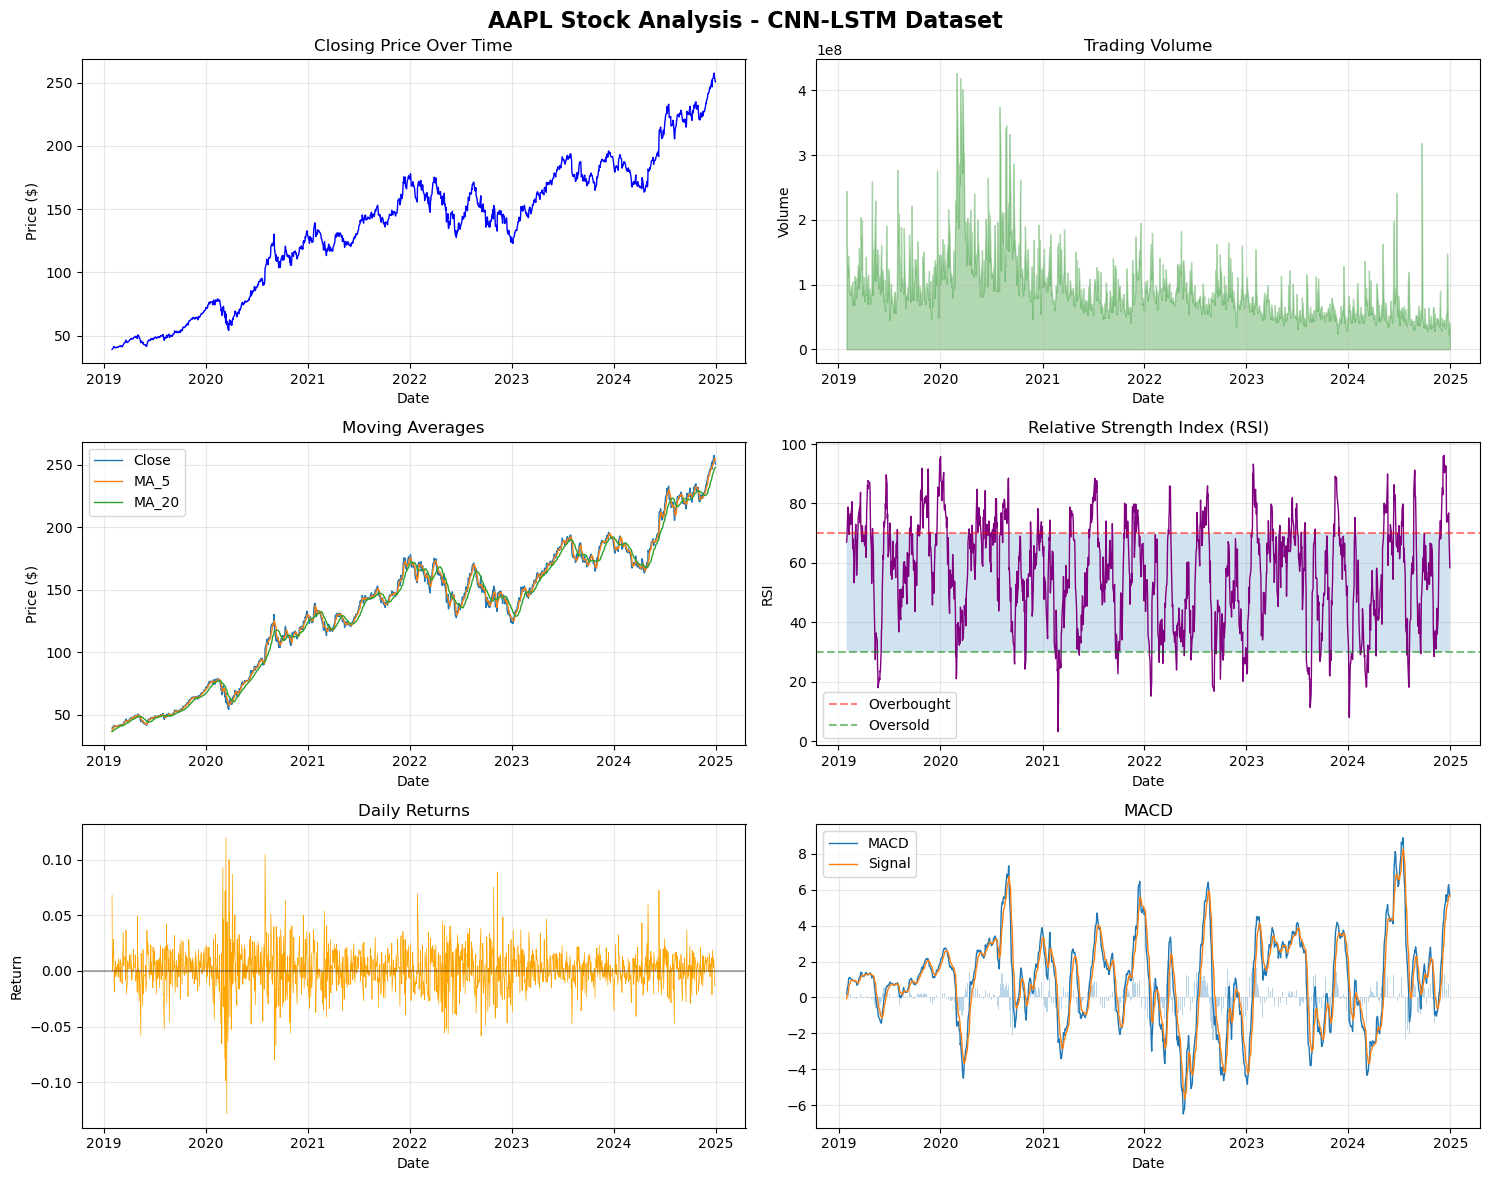

In [8]:
#Data Visualization (Volume array is now 1D)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'{ticker} Stock Analysis - CNN-LSTM Dataset', fontsize=16, fontweight='bold')

# Closing Price
axes[0, 0].plot(df_features.index, df_features['Close'], color='blue', linewidth=1)
axes[0, 0].set_title('Closing Price Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Trading Volume (using .values.ravel() to ensure 1D)
volume_values = df_features['Volume'].values.ravel()
axes[0, 1].fill_between(df_features.index, volume_values, color='green', alpha=0.3)
axes[0, 1].set_title('Trading Volume', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# Moving Averages
axes[1, 0].plot(df_features.index, df_features['Close'], label='Close', linewidth=1)
axes[1, 0].plot(df_features.index, df_features['MA_5'], label='MA_5', linewidth=1)
axes[1, 0].plot(df_features.index, df_features['MA_20'], label='MA_20', linewidth=1)
axes[1, 0].set_title('Moving Averages', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# RSI
axes[1, 1].plot(df_features.index, df_features['RSI'], color='purple', linewidth=1)
axes[1, 1].axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought')
axes[1, 1].axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold')
axes[1, 1].fill_between(df_features.index, 30, 70, alpha=0.2)
axes[1, 1].set_title('Relative Strength Index (RSI)', fontsize=12)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('RSI')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Daily Returns (ensure 1D)
returns_values = df_features['Daily_Return'].values.ravel()
axes[2, 0].plot(df_features.index, returns_values, color='orange', linewidth=0.5)
axes[2, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2, 0].set_title('Daily Returns', fontsize=12)
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('Return')
axes[2, 0].grid(True, alpha=0.3)

# MACD (ensure 1D)
macd_values = df_features['MACD'].values.ravel()
macd_signal_values = df_features['MACD_Signal'].values.ravel()
axes[2, 1].plot(df_features.index, macd_values, label='MACD', linewidth=1)
axes[2, 1].plot(df_features.index, macd_signal_values, label='Signal', linewidth=1)
# For bar plot, use the difference
macd_diff = (df_features['MACD'] - df_features['MACD_Signal']).values.ravel()
axes[2, 1].bar(df_features.index, macd_diff, alpha=0.3, width=1)
axes[2, 1].set_title('MACD', fontsize=12)
axes[2, 1].set_xlabel('Date')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
def prepare_sequences(data, target_col, feature_cols, sequence_length):
    """Prepare sequences for CNN-LSTM model"""
    X, y = [], []
    
    for i in range(len(data) - sequence_length):
        X.append(data[feature_cols].iloc[i:i+sequence_length].values)
        y.append(data[target_col].iloc[i+sequence_length])
    
    return np.array(X), np.array(y)

# Define features and target
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 
                   'Open_Close_Ratio', 'High_Low_Ratio', 'Close_Open_Ratio',
                   'MA_5', 'MA_10', 'Price_Change', 'RSI', 'MACD']

target_column = 'Close'

print(f"Number of features: {len(feature_columns)}")
print(f"Features: {feature_columns}")

Number of features: 13
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Open_Close_Ratio', 'High_Low_Ratio', 'Close_Open_Ratio', 'MA_5', 'MA_10', 'Price_Change', 'RSI', 'MACD']


In [10]:
# Normalize the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df_features_scaled = df_features.copy()
df_features_scaled[feature_columns] = scaler_X.fit_transform(df_features[feature_columns])
df_features_scaled[target_column] = scaler_y.fit_transform(df_features[[target_column]])

# Create sequences
sequence_length = 60  # Use 60 days of historical data

X, y = prepare_sequences(df_features_scaled, target_column, feature_columns, sequence_length)

print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape} (samples,)")

X shape: (1430, 60, 13) (samples, timesteps, features)
y shape: (1430, 1) (samples,)


In [12]:
 #Train-test split
split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining period: {split_idx} samples")
print(f"Testing period: {len(X) - split_idx} samples")

Training set shape: (1144, 60, 13)
Testing set shape: (286, 60, 13)

Training period: 1144 samples
Testing period: 286 samples


In [13]:
#Build CNN-LSTM model
def build_cnn_lstm(input_shape, dropout_rate=0.3):
    """Build CNN-LSTM hybrid model"""
    model = Sequential([
        Input(shape=input_shape),
        
        # CNN Layers
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        
        # LSTM Layers
        LSTM(units=100, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        LSTM(units=50, return_sequences=False, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        
        # Dense layers
        Dense(units=50, activation='relu'),
        Dropout(dropout_rate),
        Dense(units=25, activation='relu'),
        
        # Output layer
        Dense(units=1, activation='linear')
    ])
    
    return model

# Build the model
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_cnn_lstm(input_shape)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 60, 64)              │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 60, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 30, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 30, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 15, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 15, 128)             │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 15, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 15, 100)             │          91,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,475 (794.82 KB)

 Trainable params: 202,835 (792.32 KB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
#Train the model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_cnn_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

print("🚀 Starting training...")
print("="*50)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

print("\n✅ Training completed!")

🚀 Starting training...
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0902 - mae: 0.2316 - mape: 109.5739
Epoch 1: val_loss improved from None to 0.06665, saving model to best_cnn_lstm_model.h5



Epoch 1: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.0436 - mae: 0.1556 - mape: 74.0889 - val_loss: 0.0667 - val_mae: 0.2566 - val_mape: 39.9140 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0127 - mae: 0.0897 - mape: 49.1345
Epoch 2: val_loss did not improve from 0.06665
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0113 - mae: 0.0834 - mape: 41.2060 - val_loss: 0.0695 - val_mae: 0.2620 - val_mape: 40.7366 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0085 - mae: 0.0711 - mape: 40.2144
Epoch 3: val_loss improved from 0.06665 to 0.06167, saving model to best_cnn_lstm_model.h5



Epoch 3: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0081 - mae: 0.0698 - mape: 34.9856 - val_loss: 0.0617 - val_mae: 0.2467 - val_mape: 38.3476 - learning_rate: 0.0010
Epoch 4/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0062 - mae: 0.0611 - mape: 33.1792
Epoch 4: val_loss improved from 0.06167 to 0.05166, saving model to best_cnn_lstm_model.h5



Epoch 4: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0065 - mae: 0.0621 - mape: 29.5007 - val_loss: 0.0517 - val_mae: 0.2251 - val_mape: 34.9558 - learning_rate: 0.0010
Epoch 5/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0058 - mae: 0.0600 - mape: 31.8348
Epoch 5: val_loss improved from 0.05166 to 0.05038, saving model to best_cnn_lstm_model.h5



Epoch 5: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0060 - mae: 0.0610 - mape: 28.5755 - val_loss: 0.0504 - val_mae: 0.2223 - val_mape: 34.5162 - learning_rate: 0.0010
Epoch 6/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0051 - mae: 0.0556 - mape: 31.1475
Epoch 6: val_loss did not improve from 0.05038
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0048 - mae: 0.0539 - mape: 27.4822 - val_loss: 0.0546 - val_mae: 0.2316 - val_mape: 35.9725 - learning_rate: 0.0010
Epoch 7/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0036 - mae: 0.0475 - mape: 29.0744
Epoch 7: val_loss did not improve from 0.05038
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0037 - mae: 0.0479 - mape: 24.9374 - val_loss: 0.0627 - val_mae: 0.2486 - val_mape: 38.6461 - learning_rate: 0.0010
Epoch 8/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0040 - mae: 0.0474 - mape: 27.4212
Epoch 8: val_loss improved from 0.05038 to 0.04946, saving 

...


Epoch 15: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0018 - mae: 0.0333 - mape: 18.2852 - val_loss: 0.0199 - val_mae: 0.1397 - val_mape: 21.7207 - learning_rate: 0.0010
Epoch 16/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0018 - mae: 0.0322 - mape: 17.4885
Epoch 16: val_loss improved from 0.01991 to 0.01827, saving model to best_cnn_lstm_model.h5



Epoch 16: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0019 - mae: 0.0329 - mape: 16.6594 - val_loss: 0.0183 - val_mae: 0.1338 - val_mape: 20.7929 - learning_rate: 0.0010
Epoch 17/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0017 - mae: 0.0322 - mape: 19.2101
Epoch 17: val_loss improved from 0.01827 to 0.01213, saving model to best_cnn_lstm_model.h5



Epoch 17: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0017 - mae: 0.0321 - mape: 17.0319 - val_loss: 0.0121 - val_mae: 0.1084 - val_mape: 16.8484 - learning_rate: 0.0010
Epoch 18/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0017 - mae: 0.0313 - mape: 18.5437
Epoch 18: val_loss improved from 0.01213 to 0.00766, saving model to best_cnn_lstm_model.h5



Epoch 18: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0015 - mae: 0.0300 - mape: 16.4289 - val_loss: 0.0077 - val_mae: 0.0847 - val_mape: 13.1098 - learning_rate: 0.0010
Epoch 19/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0016 - mae: 0.0314 - mape: 19.9154
Epoch 19: val_loss did not improve from 0.00766
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0015 - mae: 0.0300 - mape: 16.7534 - val_loss: 0.0095 - val_mae: 0.0949 - val_mape: 14.7214 - learning_rate: 0.0010
Epoch 20/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0015 - mae: 0.0295 - mape: 16.0224
Epoch 20: val_loss did not improve from 0.00766
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0014 - mae: 0.0291 - mape: 14.6079 - val_loss: 0.0105 - val_mae: 0.1006 - val_mape: 15.6386 - learning_rate: 0.0010
Epoch 21/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0015 - mae: 0.0297 - mape: 17.6737
Epoch 21: val_loss improved from 0.00766 to 0.00708, 


Epoch 21: finished saving model to best_cnn_lstm_model.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0014 - mae: 0.0292 - mape: 15.3393 - val_loss: 0.0071 - val_mae: 0.0811 - val_mape: 12.5353 - learning_rate: 0.0010
Epoch 22/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0015 - mae: 0.0294 - mape: 17.4282
Epoch 22: val_loss did not improve from 0.00708
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0014 - mae: 0.0292 - mape: 15.3589 - val_loss: 0.0072 - val_mae: 0.0822 - val_mape: 12.7653 - learning_rate: 0.0010
Epoch 23/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0014 - mae: 0.0287 - mape: 17.9015
Epoch 23: val_loss did not improve from 0.00708
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0013 - mae: 0.0281 - mape: 15.6941 - val_loss: 0.0086 - val_mae: 0.0902 - val_mape: 13.9649 - learning_rate: 0.0010
Epoch 24/100
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0013 - mae: 0.0277 - mape: 16.8473
Epoch 24: val_loss did not improve from 0.00708
33/33

In [15]:
#Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse transform
y_train_actual = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_train_pred_actual = scaler_y.inverse_transform(y_train_pred)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler_y.inverse_transform(y_test_pred)

print("✅ Predictions made")

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
✅ Predictions made


In [16]:
# Calculate metrics
def calculate_metrics(y_true, y_pred):
    """Calculate various regression metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, mape, r2

print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)

train_metrics = calculate_metrics(y_train_actual, y_train_pred_actual)
print(f"\n📈 TRAINING SET:")
print(f"  MSE:  {train_metrics[0]:.4f}")
print(f"  RMSE: ${train_metrics[1]:.2f}")
print(f"  MAE:  ${train_metrics[2]:.2f}")
print(f"  MAPE: {train_metrics[3]:.2f}%")
print(f"  R²:   {train_metrics[4]:.4f}")

test_metrics = calculate_metrics(y_test_actual, y_test_pred_actual)
print(f"\n📉 TESTING SET:")
print(f"  MSE:  {test_metrics[0]:.4f}")
print(f"  RMSE: ${test_metrics[1]:.2f}")
print(f"  MAE:  ${test_metrics[2]:.2f}")
print(f"  MAPE: {test_metrics[3]:.2f}%")
print(f"  R²:   {test_metrics[4]:.4f}")

MODEL EVALUATION METRICS

📈 TRAINING SET:
  MSE:  59.1446
  RMSE: $7.69
  MAE:  $5.68
  MAPE: 4.98%
  R²:   0.9667

📉 TESTING SET:
  MSE:  1770.5393
  RMSE: $42.08
  MAE:  $37.46
  MAPE: 17.56%
  R²:   -1.9762


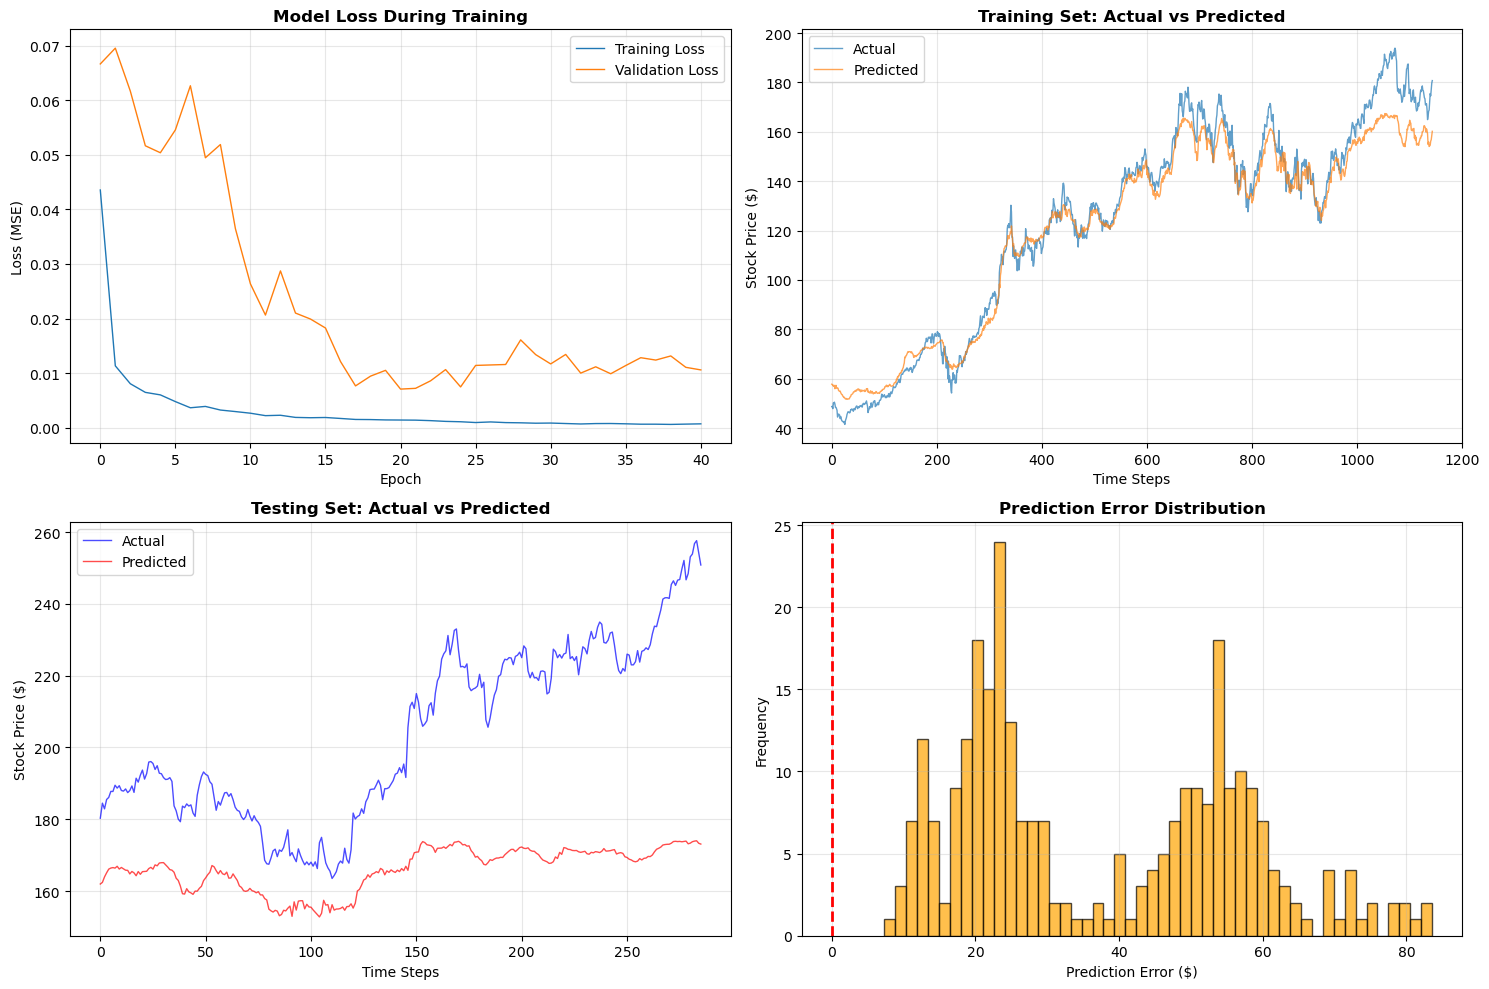

In [17]:
#Visualize results (FIXED)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=1)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=1)
axes[0, 0].set_title('Model Loss During Training', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training predictions (FIXED - flatten arrays)
train_actual_flat = y_train_actual.flatten()
train_pred_flat = y_train_pred_actual.flatten()
axes[0, 1].plot(train_actual_flat, label='Actual', linewidth=1, alpha=0.7)
axes[0, 1].plot(train_pred_flat, label='Predicted', linewidth=1, alpha=0.7)
axes[0, 1].set_title('Training Set: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Steps')
axes[0, 1].set_ylabel('Stock Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Testing predictions (FIXED - flatten arrays)
test_actual_flat = y_test_actual.flatten()
test_pred_flat = y_test_pred_actual.flatten()
axes[1, 0].plot(test_actual_flat, label='Actual', linewidth=1, alpha=0.7, color='blue')
axes[1, 0].plot(test_pred_flat, label='Predicted', linewidth=1, alpha=0.7, color='red')
axes[1, 0].set_title('Testing Set: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Steps')
axes[1, 0].set_ylabel('Stock Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error distribution (FIXED - flatten arrays)
errors = (test_actual_flat - test_pred_flat)
axes[1, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Prediction Error ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FUTURE PRICE PREDICTIONS

Next 10 days predictions for AAPL:
Day 1: $173.09
Day 2: $173.03
Day 3: $172.98
Day 4: $172.38
Day 5: $172.25
Day 6: $171.77
Day 7: $171.56
Day 8: $170.68
Day 9: $170.56
Day 10: $170.32


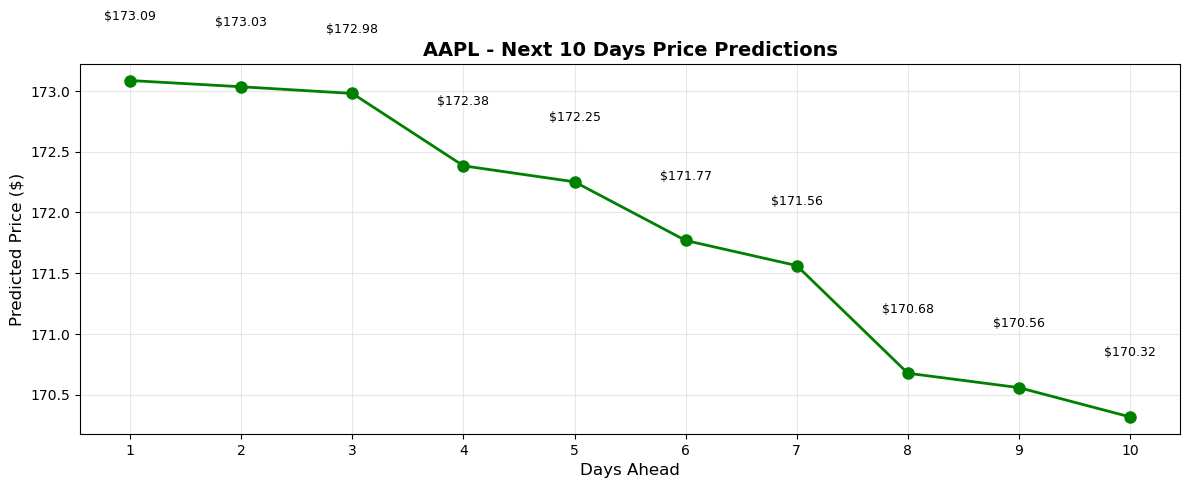

In [18]:
#Future predictions
def predict_future_days(model, last_sequence, scaler_y, days=10):
    """Predict future stock prices"""
    predictions = []
    current_sequence = last_sequence.copy()
    
    for i in range(days):
        next_pred_scaled = model.predict(current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1]), verbose=0)
        next_pred = scaler_y.inverse_transform(next_pred_scaled)
        predictions.append(next_pred[0, 0])
        
        # Update sequence
        new_row = current_sequence[-1].copy()
        new_row[3] = next_pred_scaled[0, 0]  # Update close price (index 3)
        current_sequence = np.vstack([current_sequence[1:], new_row])
    
    return predictions

# Get last sequence and predict
last_sequence = X_test[-1]
future_predictions = predict_future_days(model, last_sequence, scaler_y, days=10)

print("="*50)
print("FUTURE PRICE PREDICTIONS")
print("="*50)
print(f"\nNext 10 days predictions for {ticker}:")
for i, price in enumerate(future_predictions, 1):
    print(f"Day {i}: ${price:.2f}")

# Visualize future predictions
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), future_predictions, marker='o', linewidth=2, markersize=8, color='green')
plt.title(f'{ticker} - Next 10 Days Price Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Days Ahead', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
for i, price in enumerate(future_predictions, 1):
    plt.text(i, price + 0.5, f'${price:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
#Save model
import joblib
import pickle

# Save the scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# Save complete pipeline
pipeline = {
    'model': model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_columns': feature_columns,
    'sequence_length': sequence_length
}

with open('cnn_lstm_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("✅ Model and pipeline saved successfully!")

✅ Model and pipeline saved successfully!


In [20]:
# Load and test the saved model
import joblib
import pickle
from tensorflow.keras.models import load_model

# Load the saved pipeline
with open('cnn_lstm_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

loaded_model = loaded_pipeline['model']
loaded_scaler_X = loaded_pipeline['scaler_X']
loaded_scaler_y = loaded_pipeline['scaler_y']
feature_columns = loaded_pipeline['feature_columns']
sequence_length = loaded_pipeline['sequence_length']

print("✅ Model loaded successfully!")
print(f"Model type: {type(loaded_model)}")

✅ Model loaded successfully!
Model type: <class 'keras.src.models.sequential.Sequential'>


In [21]:
#Predict for any new stock
def quick_predict(ticker_symbol):
    """Quick prediction for any stock"""
    print(f"\n🔮 Predicting for {ticker_symbol}...")
    
    # Fetch recent data
    import yfinance as yf
    from datetime import datetime, timedelta
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=200)
    
    df_new = yf.download(ticker_symbol, start=start_date, end=end_date, progress=False)
    
    # Create features (using your existing create_features function)
    df_new_features = create_features(df_new)
    df_new_features = df_new_features.dropna()
    
    if len(df_new_features) >= sequence_length:
        # Prepare last sequence
        last_sequence = df_new_features[feature_columns].iloc[-sequence_length:].values
        last_sequence_scaled = loaded_scaler_X.transform(last_sequence)
        
        # Predict
        pred_scaled = loaded_model.predict(
            last_sequence_scaled.reshape(1, sequence_length, len(feature_columns))
        )
        pred_price = loaded_scaler_y.inverse_transform(pred_scaled)
        
        print(f"✅ Predicted next day price for {ticker_symbol}: ${pred_price[0,0]:.2f}")
        return pred_price[0,0]
    else:
        print(f"❌ Insufficient data for {ticker_symbol}")
        return None

# Test on different stocks
for stock in ['AAPL', 'GOOGL', 'MSFT', 'TSLA']:
    quick_predict(stock)


🔮 Predicting for AAPL...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 951ms/step
✅ Predicted next day price for AAPL: $170.86

🔮 Predicting for GOOGL...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
✅ Predicted next day price for GOOGL: $171.45

🔮 Predicting for MSFT...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
✅ Predicted next day price for MSFT: $170.84

🔮 Predicting for TSLA...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
✅ Predicted next day price for TSLA: $172.66


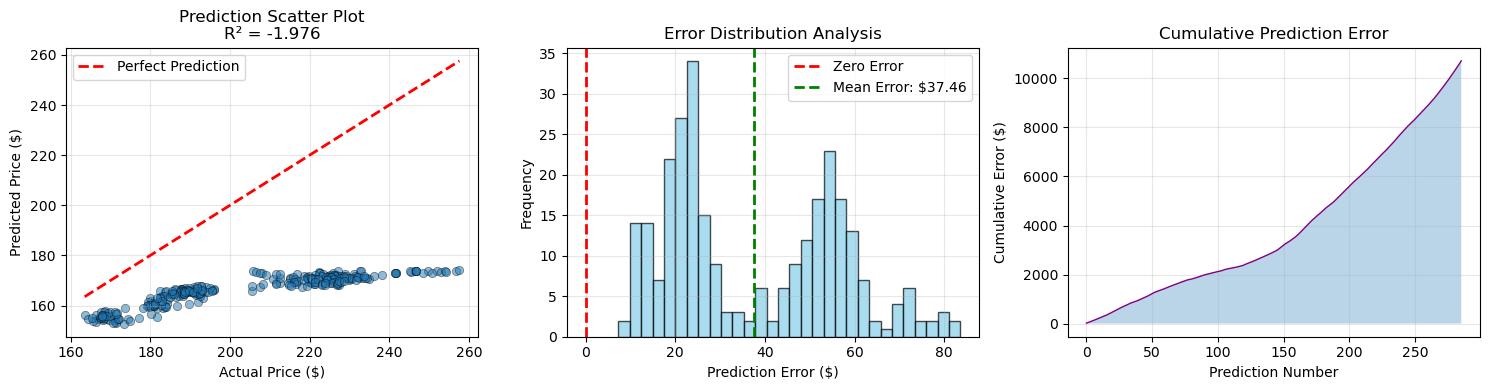


📊 Error Statistics:
  Mean Error: $37.46
  Std Deviation: $19.16
  95% Confidence Interval: [$11.61, $75.87]


In [22]:
#Create performance dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Actual vs Predicted Scatter Plot
axes[0].scatter(test_actual_flat, test_pred_flat, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([test_actual_flat.min(), test_actual_flat.max()], 
             [test_actual_flat.min(), test_actual_flat.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Prediction Scatter Plot\nR² = {test_metrics[4]:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Error Distribution with Statistics
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2, label=f'Mean Error: ${np.mean(errors):.2f}')
axes[1].set_xlabel('Prediction Error ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Distribution Analysis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Cumulative Error
cumulative_error = np.cumsum(errors)
axes[2].plot(cumulative_error, color='purple', linewidth=1)
axes[2].fill_between(range(len(errors)), 0, cumulative_error, alpha=0.3)
axes[2].set_xlabel('Prediction Number')
axes[2].set_ylabel('Cumulative Error ($)')
axes[2].set_title('Cumulative Prediction Error')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Error Statistics:")
print(f"  Mean Error: ${np.mean(errors):.2f}")
print(f"  Std Deviation: ${np.std(errors):.2f}")
print(f"  95% Confidence Interval: [${np.percentile(errors, 2.5):.2f}, ${np.percentile(errors, 97.5):.2f}]")